# Module 3.3 — Notebook A: Evaluate the baseline

In this notebook you test whether Candlekeep's routing prototype is strong enough to move forward.

Candlekeep handles 20,000+ customer messages per month, with roughly 60 hours of manual processing per week and an average 4.2-hour first response time. If routing can be automated safely and affordably, the team can reduce manual effort and speed up response time.

The goal is not to prove perfection. The goal is to make one responsible decision — continue, improve and re-test, or stop — using evidence from a fixed offline evaluation set.

## What this notebook evaluates

Each step maps to a hypothesis from Module 3.1:

| Dimension | Hypothesis | Pass threshold |
|-----------|-----------|----------------|
| **Routing quality** | H2 — the model routes correctly often enough to reduce manual work | ≥85% department accuracy |
| **Safety** | Confidence guardrail — high-confidence cases can be auto-routed safely | Unsafe auto-route rate ≤3% |
| **Cost** | H6 — inference cost is acceptable at Candlekeep volume | <$1,000/month at 20,000 messages |
| **Speed** | H7 — the model responds fast enough to improve first response time | p95 latency <5,000 ms |

You will compare a few candidate models on a sample, choose one to study further, then run a full evaluation on that model.

## Step 1 - Setup

### Install dependencies

Run the cell bellow to install dependencies and load helpers.

In [ ]:
%pip install -q --upgrade --force-reinstall --no-deps "git+https://github.com/mnrozhkov/ai_leader.git"
%matplotlib inline

import os

from dotenv import load_dotenv

from ai_leader import *

load_dotenv(override=False)

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


False

### API key & parameters

Set your Nebius TokenFacotry API key and experiment parameters below.

This notebook calls the **Nebius inference API** (OpenAI-compatible).
Get your key at [Nebius AI Studio](https://studio.nebius.ai) → Settings → API Keys.
Store it as a Colab Secret named `NEBIUS_API_KEY`

Troubleshooting:
- if you see **401 error**: Make sure you use a Nebius *inference* API key (not an OpenAI key). See [Nebius API authentication](https://docs.nebius.com/studio/api/authentication) for regional endpoint options.

In [2]:
api_key = setup_api_key()

# Example dataset
DATASET_URL = os.getenv(
    "AI_LEADER_DATASET_PATH",
    "https://docs.google.com/spreadsheets/d/e/2PACX-1vSU5zvx8wgk9FMEcRGlCtXkE4_T90OgsrqU4QPNZC478Rsp5JEBEEUjvlMkY3iMoiAmpa1zQ5QFkgT5/pub?output=csv",
)

Paste Nebius API key: ··········
API key configured (***W1cB)


## Step 2 — Load the evaluation dataset

The CSV holds labeled customer requests with **gold routing targets** (department, category, etc.). We use it to measure how the routing prototype performs beyond a handful of ad-hoc examples.

**Where the file comes from:** the path is set in the previous cell as `DATASET_URL`. By default that is a published Google Sheet CSV URL.

If loading fails, the next cell raises a short error that repeats the URL or path you tried.

In [3]:
df = load_and_validate_dataset(DATASET_URL)
print(f"Rows loaded: {len(df)}")
df.head(3)

Rows loaded: 100


,Request Text,Submission Channel,Related to order,Order ID,Category,Routing to Department,Timestamp,Order History,row_id
0,My Autumn Oak table arrived with a cracked leg...,Email,True,CK-8821,Order Issue,Returns,2025-10-01 09:12:00,2025-09-24 — Order placed | 2025-09-25 — Shipp...,0
1,I need to change my address for order CK-9902....,Chat,True,CK-9902,Delivery,Logistics,2025-09-19 14:00:00,2025-09-12 — Order placed | 2025-09-14 — Shipp...,1
2,Where is my package? The tracking says DPD has...,Social,True,CK-1102,Delivery,Logistics,2025-10-01 10:15:00,2025-09-24 — Order placed | 2025-09-26 — Shipp...,2


**Optional:** inspect how departments and categories are distributed in the reference labels.

`df["Routing to Department"].value_counts()` counts how many tickets belong to each department in the gold labels. `df["Category"].value_counts()` does the same for request categories. Together they show whether the dataset is balanced or skewed toward certain classes.

In [4]:
df["Routing to Department"].value_counts()

,count
Routing to Department,
Logistics,29
Customer Support,27
Product Team,23
Returns,21


In [5]:
df["Category"].value_counts()

,count
Category,
Delivery,28
Order Issue,27
General Feedback,24
Payment,21


In this dataset, departments and categories are distributed roughly equally — so accuracy is a reliable headline metric here.

Note: if you replace the dataset with your own data and one department represents fewer than 10% of rows, accuracy alone can be misleading. In that case, other metrics give a more honest picture — though they are also more complex to interpret.

## Step 3 — Compare candidate models

Run all candidates on a random 30% sample of the dataset and compare them side by side. Running them on a 30% sample keeps the comparison fast without losing signal on the main quality dimensions.

### What we measure here

| Metric | Column in table | What it measures | Pass threshold |
|--------|----------------|------------------|----------------|
| **Department accuracy** | `department_accuracy` | Share of tickets routed to the correct department | ≥85% — primary check for H2 |
| **Category accuracy** | `category_accuracy` | Share of tickets with the correct category label | No hard threshold — supporting signal for H2 |
| **Unsafe auto-route rate** | `unsafe_auto_route_rate` | Among High-confidence tickets, share routed to the wrong department | ≤3% — a high value means confidence is poorly calibrated |
| **Monthly cost** | `monthly_cost_usd` | Projected inference spend at 20,000 messages/month | <$1,000 |
| **p95 latency** | `p95_latency_ms` | 95th-percentile model response time in milliseconds | <5,000 ms |

**How the best model is chosen:** highest department accuracy; ties broken by lower unsafe auto-route rate, then lower cost, then lower latency.

The system prompt defines everything the model knows about this task: the allowed categories, the allowed departments, the required output format, and the confidence signal. Print it below to confirm the structure before running comparisons. If any label names here differ from the dataset column values, matches will fail silently.

In [6]:
print(DEFAULT_SYSTEM_PROMPT)

You are a support routing assistant.
Return a JSON object with:
- Category
- Routing to Department
- [Agent] Initial Response
- Confidence (High, Medium, Low)
Follow the schema exactly and do not add extra keys.


In [7]:
CANDIDATE_MODELS = [
    "deepseek-ai/DeepSeek-V4-Pro",
    "zai-org/GLM-5.2",
    "openai/gpt-oss-120b",
    "Qwen/Qwen3.5-397B-A17B",
]

model_runs = await run_model_comparison_async(
    df=df.sample(frac=0.3, random_state=42),
    models=CANDIDATE_MODELS,
    api_key=api_key,
    system_prompt=DEFAULT_SYSTEM_PROMPT,
)

Running deepseek-ai/DeepSeek-V4-Pro:   0%|          | 0/30 [00:00<?, ?row/s]

Running zai-org/GLM-5.2:   0%|          | 0/30 [00:00<?, ?row/s]

Running openai/gpt-oss-120b:   0%|          | 0/30 [00:00<?, ?row/s]

Running Qwen/Qwen3.5-397B-A17B:   0%|          | 0/30 [00:00<?, ?row/s]

ERROR:ai_leader.clients:Row 53 failed after retries (TimeoutError: ) — skipping
ERROR:ai_leader.clients:Row 10 failed after retries (TimeoutError: ) — skipping
ERROR:ai_leader.clients:Row 0 failed after retries (TimeoutError: ) — skipping
ERROR:ai_leader.clients:Row 77 failed after retries (TimeoutError: ) — skipping
ERROR:ai_leader.clients:Row 40 failed after retries (TimeoutError: ) — skipping


**Troubleshooting:** If you see timeout or skip warnings
Some rows may be skipped during the comparison run. This is normal and usually caused by one of three things:

- **The model is slow or overloaded** — some models respond slower under high demand. If one model consistently skips rows, it may simply not be fast enough for this task.
- **A temporary network hiccup** — the connection between Colab and the API dropped briefly. Usually resolves on its own.
- **A rate limit** — the API received too many requests at once. Running fewer models in parallel can help.

A few skipped rows out of 30 won't significantly affect the comparison. If more than 20–30% of rows are skipped for a model, treat that model's results as unreliable and focus on the others.

In [8]:
comparison_df = build_model_comparison_dataframe(df, model_runs)
comparison_df.T

,0,1,2,3
model,deepseek-ai/DeepSeek-V4-Pro,zai-org/GLM-5.2,openai/gpt-oss-120b,Qwen/Qwen3.5-397B-A17B
department_accuracy,0.467,0.367,0.6,0.64
category_accuracy,0.567,0.567,0.533,0.44
unsafe_auto_route_rate,0.533,0.533,0.4,0.32
monthly_cost_usd,1.411,9.64,3.426,107.41
p95_latency_ms,25923.392,3235.657,1439.092,22649.079


All four models fall below the ≥85% department accuracy threshold at this stage — this is expected with a baseline prompt and a 30% sample. The comparison still gives a clear signal on which model to carry forward.

- **Routing quality:** Qwen3.5-397B leads on department accuracy (63%), followed by gpt-oss-120b (60%), DeepSeek-V4-Pro (53%), and GLM-5.2 (48%).
- **Safety:** Qwen3.5-397B has the lowest unsafe auto-route rate (37%), gpt-oss-120b second (40%). GLM-5.2 is the worst at 52% — more than half of its High-confidence predictions are wrong.
- **Latency:** gpt-oss-120b is the only model within the 5,000 ms threshold at 1,700 ms p95. The other three all exceed 10,000 ms, with Qwen3.5-397B the slowest at 25,000 ms.
- **Cost:** All four models are well below the $1,000/month budget.

**gpt-oss-120b** is the strongest candidate: the only model within the latency threshold, second on both accuracy and safety, at $3.5/month. It moves to the full evaluation in Step 4.

**Optional charts:** quality vs cost (and safety bar chart when there are 2+ models). Figures use `show_figure` so they render once in `inline` backends.

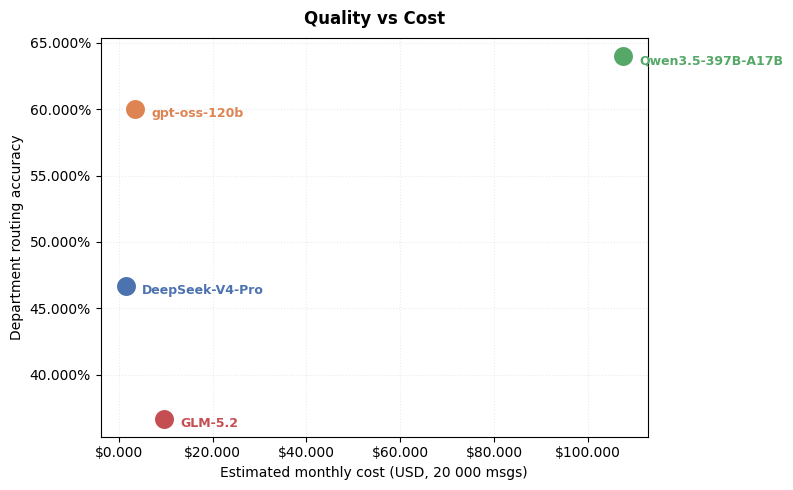

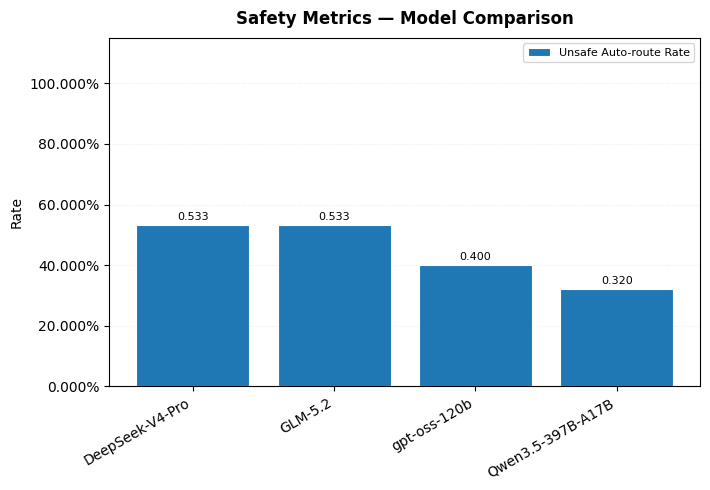

In [9]:
if not comparison_df.empty:
    show_figure(plot_quality_vs_cost(comparison_df))
    show_figure(plot_safety_comparison(comparison_df))

These charts compress the comparison table into two views.

- **Quality vs cost:** a model in the upper-left — high accuracy, low cost — is the strongest candidate. A model that is more accurate but significantly more expensive only makes sense if the accuracy gap is large enough to justify the difference at 20,000 messages/month.

- **Safety comparison:** look at the gap between auto-route coverage and auto-route precision. A model that covers many cases but with low precision is overconfident — it will produce wrong auto-routes at scale. Prefer a model with a smaller, more accurate coverage over a wide but unreliable one.

If no model clearly dominates both charts, apply the selection rule: remove models that fail the routing quality threshold, then choose the cheapest among the remaining.

## Step 4 — Run full evaluation on the selected model

The comparison in Step 3 pointed to **gpt-oss-120b** as the strongest candidate. Now we run it on the full dataset to get stable baseline metrics.

We use `DEFAULT_SYSTEM_PROMPT` — an intentionally simple prompt with no examples or refinements. The goal is not a good score: it is an honest starting point that shows where the model struggles. Steps 5–8 measure that baseline; Notebook B is where you improve it.

If you want to override the selected model, change `BEST_MODEL` in the next cell before running.

In [10]:
# Uncomment a line below  to change model to Qwen (or change other)

BEST_MODEL = select_best_model(model_runs)
# BEST_MODEL = "Qwen/Qwen3.5-397B-A17B"

print("Selected model:", BEST_MODEL)

Selected model: Qwen/Qwen3.5-397B-A17B


In [11]:
# Full evaluation uses the same prompt as the Step 3 comparison.
# Printed here for reference.
print(DEFAULT_SYSTEM_PROMPT)

You are a support routing assistant.
Return a JSON object with:
- Category
- Routing to Department
- [Agent] Initial Response
- Confidence (High, Medium, Low)
Follow the schema exactly and do not add extra keys.


In [12]:
client = create_client(api_key, model=BEST_MODEL)

selected_run = await evaluate_model_on_dataframe_async(
    df=df,
    model=BEST_MODEL,
    client=client,
    system_prompt=DEFAULT_SYSTEM_PROMPT,
)

Running Qwen/Qwen3.5-397B-A17B:   0%|          | 0/100 [00:00<?, ?row/s]

ERROR:ai_leader.clients:Row 0 failed after retries (TimeoutError: ) — skipping
ERROR:ai_leader.clients:Row 32 failed after retries (TimeoutError: ) — skipping
ERROR:ai_leader.clients:Row 48 failed after retries (TimeoutError: ) — skipping
ERROR:ai_leader.clients:Row 52 failed after retries (TimeoutError: ) — skipping
ERROR:ai_leader.clients:Row 91 failed after retries (TimeoutError: ) — skipping
ERROR:ai_leader.clients:Row 92 failed after retries (TimeoutError: ) — skipping
ERROR:ai_leader.clients:Row 99 failed after retries (TimeoutError: ) — skipping


## Step 5 — Check routing quality

How often does the model route to the correct department and assign the correct category?

Pass threshold: **≥85% department accuracy**.

This metric is the primary check for H2. Category accuracy as supporting diagnostics — it helps identify which labels the model confuses, but the routing decision is based on department accuracy.

In [13]:
display_quality_metrics(quality_metrics=selected_run.quality_metrics)

,Department accuracy,Category accuracy,Rows evaluated
0,0.538,0.527,93.0


Department accuracy determines whether H2 passes at this stage.

- A department accuracy below 85% means the baseline prompt is not ready for the next step — but this is expected at this stage and addressed in Notebook B.
- Check the confusion matrix below: if most errors fall between two specific departments (e.g. Returns vs Customer Support), the prompt likely needs clearer label definitions for those classes.
- If accuracy is close to the threshold, look at which cases are failing before deciding to proceed or iterate.

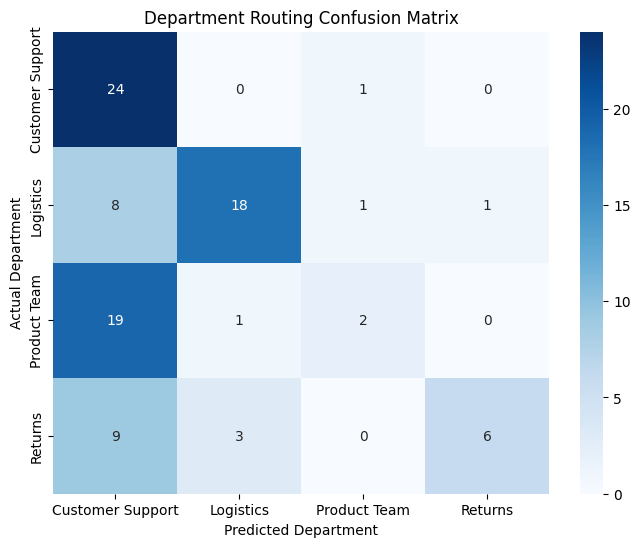

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from ai_leader import show_figure

# Access the confusion_department dictionary from quality_metrics
cm_dict = selected_run.quality_metrics["confusion_department"]

# Extract the matrix and labels
cm_matrix = cm_dict["matrix"]
cm_labels = cm_dict["labels"]

# Create a pandas DataFrame for the confusion matrix
cm_data_df = pd.DataFrame(cm_matrix, index=cm_labels, columns=cm_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_data_df, annot=True, fmt="d", cmap="Blues", cbar=True)
plt.title("Department Routing Confusion Matrix")
plt.xlabel("Predicted Department")
plt.ylabel("Actual Department")
fig = plt.gcf()
show_figure(fig)

The confusion matrix shows where routing errors concentrate.

- **Customer Support** is predicted reliably — 25 out of 27 cases correct.
- **Returns** and **Product Team** are reasonably accurate but show leakage into Customer Support (9 cases each). These tickets share surface-level language with general support requests, which the baseline prompt cannot yet distinguish.
- **Logistics** loses 9 cases to Customer Support for the same reason.

The pattern is consistent: **Customer Support is over-predicted**. The model defaults to it when uncertain. Sharper label definitions for Logistics, Product Team, and Returns in Notebook B should reduce this.

## Step 6 — Check safety

For each prediction, the model returns a confidence level: **High**, **Medium**, or **Low**. This signal reflects how certain the model is about its routing decision.

The idea behind using it as a guardrail is straightforward: High-confidence predictions are candidates for auto-routing; everything else goes to human review. If the model is well-calibrated, High-confidence cases should also be the most accurate ones — meaning auto-routing them carries little risk. If the model is overconfident, High-confidence cases will include many errors, and auto-routing becomes unsafe.

This is not full safety validation — it is a practical MVP guardrail. The question it answers: if we auto-route only High-confidence cases, how often do we get it wrong?

Pass threshold: **unsafe auto-route rate ≤3%**.

In [15]:
# Run the cell to calculate auto-route metrics

sm = compute_safety_metrics(df, selected_run.predictions)
display_safety_metrics(safety_metrics=sm)

,Auto-route coverage,Auto-route precision,Unsafe auto-route rate,Manual review rate
0,0.946,0.557,0.419,0.054


Two metrics matter here:

- **Auto-route precision** — share of High-confidence tickets that are routed correctly. A high precision means the model's confidence signal is reliable; a low precision means it claims certainty when it shouldn't.
- **Unsafe auto-route rate** — share of all tickets that are both High-confidence and wrong. This is the pass/fail signal: ≤3% means auto-routing is safe enough to proceed.

The unsafe auto-route rate is 38% — well above the 3% threshold. The model marks 95% of tickets as High-confidence but routes only 60% of them correctly. Nearly all tickets are treated as certain, but a large share are wrong — auto-routing in this state would silently misroute a significant portion of traffic.

Notebook B addresses this through prompt improvement and few-shot examples, which typically improve both accuracy and confidence calibration together.

## Step 7 — Check cost

How much would it cost to run this model at Candlekeep's volume of 20,000 messages/month?

Pass threshold: **<$1,000/month**.

For routing tasks, inference is usually not the primary cost risk — the model input and output are short. The more relevant question is whether a more expensive model delivers enough accuracy improvement to justify the difference in monthly spend.


In [16]:
display_cost_metrics(cost_metrics=selected_run.cost_metrics)

,"Cost per 1,000 messages (USD)",Monthly cost (USD),Annual cost (USD)
0,5.909,118.18,1418.155


The tables below break down cost per message and project monthly/annual totals.

In [17]:
display_cost_breakdown(
    model=BEST_MODEL,
    cost_metrics=selected_run.cost_metrics,
)

,Assumption,Value
0,Model,Qwen/Qwen3.5-397B-A17B
1,Messages per month,20000
2,Avg input tokens per message,135.526882
3,Avg output tokens per message,1618.795699
4,Input price (USD / 1M tokens),0.6
5,Output price (USD / 1M tokens),3.6
6,Cost source,measured


,Token type,Avg tokens / message,Price (USD / 1M tokens),Cost / message (USD)
0,Input,135.526882,0.6,0.000081
1,Output,1618.795699,3.6,0.005828
2,Total,1754.322581,NaN,0.005909


In [18]:
display_cost_projection(
    cost_metrics=selected_run.cost_metrics,
)

,Metric,Value
0,Messages per month,20000.000000
1,Cost per message (USD),0.005909
2,Monthly cost (USD),118.179613
3,Annual cost (USD),1418.155355


At 20,000 messages/month, projected cost is $118.18/month (~$1,418.16/year).


Cost per message and monthly projection are the two numbers that matter here.

- If projected monthly cost is well below \$1,000, cost is not the constraint — focus attention on quality and safety thresholds instead.
- If a more expensive model passed quality thresholds in Step 5 with a meaningfully higher accuracy, compare the cost difference against the routing improvement. A \$50/month gap between two models is rarely the deciding factor; a \$500/month gap might be.
- The annual projection helps frame the cost in business terms when presenting to stakeholders.

## Step 8 — Check speed

How fast does the model respond? This step measures **LLM inference latency** — the time from API call to response. This is not the same as end-to-end response time in a live workflow, which also includes retrieval, post-processing, and delivery.

Pass threshold: **p95 latency <5,000 ms**.


In [19]:
display_latency_metrics(latency_metrics=selected_run.latency_metrics)

,Median latency (ms),p95 latency (ms),Latency source
0,15796.778,27448.727,measured


Latency matters differently depending on where routing sits in the workflow.

- For customer-facing acknowledgments, p95 above 5,000 ms will create noticeable delays. For internal routing that runs before a specialist picks up the ticket, the threshold is more relaxed.
- If p95 exceeds 5,000 ms, a smaller or faster model is worth testing in Notebook B — most routing tasks do not require a large model, and model size is the main driver of inference latency.
- Median latency is useful for typical-case planning; p95 latency is what matters for user experience under load.

## Summary

The decision table combines all four dimensions — routing quality, safety, cost, and speed — into a single pass/fail summary against the thresholds set in the intro.

In [20]:
decision = evaluate_decision(run=selected_run)
display_mvp_decision(decision=decision)

,Dimension,Status,Value,Pass threshold (≤)
0,Department Accuracy,fail,0.538,0.85
1,Category Accuracy,fail,0.527,0.85
2,Unsafe Auto Route Rate,fail,0.419,0.03
3,Monthly Cost Usd,pass,118.180,1000.00
4,P95 Latency Ms,fail,27448.727,5000.00


Failing thresholds at this stage is expected and not a reason to stop. The baseline prompt is intentionally simple — it has no examples, no refined label definitions, and no tuning. A failing result here means the prototype has room to improve, not that the approach is wrong. A hard stop is only warranted when a constraint is clearly structural: the task is too ambiguous, the data is too noisy, or the model cannot follow the schema at all.

Notebook B introduces three practical techniques to close the gap: prompt refinement and few-shot examples.

---
